In [ ]:
import os
from tqdm import tqdm

import pandas as pd
import numpy as np
import cv2
# import os # to accsses folders
import matplotlib.pyplot as plt
import seaborn as sns

# encoding , scaling
from sklearn.preprocessing import StandardScaler,   label_binarize

# models
from sklearn.cluster import KMeans

# evaluation ----
# from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, mean_squared_error,roc_curve, roc_auc_score


In [6]:
dataset_path = r"C:\Users\dohah\Documents\Projects\Detecting Malaria Model\MachineLearningProject\img_dataset"

Parasitized_path = folder_path = os.path.join(dataset_path, 'Parasitized')
Uninfected_path = folder_path = os.path.join(dataset_path, 'Uninfected')


In [7]:
def load_images_optimized(folder_path, label, target_size=(64,64)):
    images = []
    labels = []
    count = 0
    for root, dirs, files in os.walk(folder_path):
        for filename in tqdm(files, desc=f"Loading {folder_path}"):
            
            # Skip non-images
            if not (filename.lower().endswith(".png") or filename.lower().endswith(".jpg") or filename.lower().endswith(".jpeg")):
                continue
            img_path = os.path.join(root, filename)
            img = cv2.imread(img_path)
            if img is None:
                continue
            # Resize
            img = cv2.resize(img, target_size)
            # Convert to grayscale
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            # Normalize [0,1]
            img = img.astype('float32') / 255.0

            images.append(img)
            labels.append(label)
            count += 1
    return images, labels, count

# Load images
parasitized_images, parasitized_labels, count_p = load_images_optimized(Parasitized_path, 1)
uninfected_images, uninfected_labels, count_u = load_images_optimized(Uninfected_path, 0)

# Combine images and labels
images = parasitized_images + uninfected_images
labels = parasitized_labels + uninfected_labels

print(f"Parasitized images loaded: {count_p}")
print(f"Uninfected images loaded: {count_u}")
print(f"Total images loaded: {len(images)}")

Loading C:\Users\dohah\Documents\Projects\Detecting Malaria Model\MachineLearningProject\img_dataset\Parasitized: 100%|██████████| 6/6 [00:00<00:00, 1865.79it/s]
Loading C:\Users\dohah\Documents\Projects\Detecting Malaria Model\MachineLearningProject\img_dataset\Uninfected: 100%|██████████| 6/6 [00:00<00:00, 2824.45it/s]

Parasitized images loaded: 6
Uninfected images loaded: 6
Total images loaded: 12


In [ ]:
#DELETE
# Flatten all lists from dictionary into one list
all_images = []

for folder_name in processed_images:
    all_images.extend(processed_images[folder_name])  # extend عشان يحط كل الصور في قائمة واحدة

# Convert to numpy array
X = np.array(all_images)

print("\n✅ Dataset ready for unsupervised learning!")
print("Shape:", X.shape)

In [ ]:
plt.figure(figsize=(15, 3))
for i in range(12):
    plt.subplot(1, 12, i + 1)
    plt.imshow(all_images[i].reshape(128, 128), cmap='gray')
    plt.axis('off')

plt.show()

In [ ]:
# 3alia delete

# تحويل كل الصور لـ grayscale فقط
gray_images = [cv2.cvtColor(img, cv2.COLOR_RGB2GRAY) for img in resized_images]

print("All images converted to grayscale.")
print("gray_images list length:", len(gray_images))

# normalize القيم [0,1]
normalized_images = [np.array(img, dtype='float32') / 255.0 for img in gray_images]

# تحويل لمصفوفة numpy
X_gray = np.array(normalized_images, dtype='float32')

print("Pixel values normalized to range 0-1.")
print("X_gray shape:", X_gray.shape)

# Flatten كل الصور
X_flat = X_gray.reshape(X_gray.shape[0], -1)  # 27558 × 4096

print("Images flattened. Each image shape:", X_flat[0].shape)

X = X_flat.astype('float32')
y = np.array(labels, dtype='int')

print("X shape:", X.shape)
print("y shape:", y.shape)



In [12]:
X = np.array([img.flatten() for img in images], dtype='float32')
y = np.array(labels, dtype='int')

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (12, 4096)
y shape: (12,)


In [13]:
kmeans = KMeans(n_clusters=2, random_state=42)
labels = kmeans.fit_predict(X)

print(labels[:20])

[1 0 1 0 0 1 1 1 1 1 1 1]


# **DELETE** after

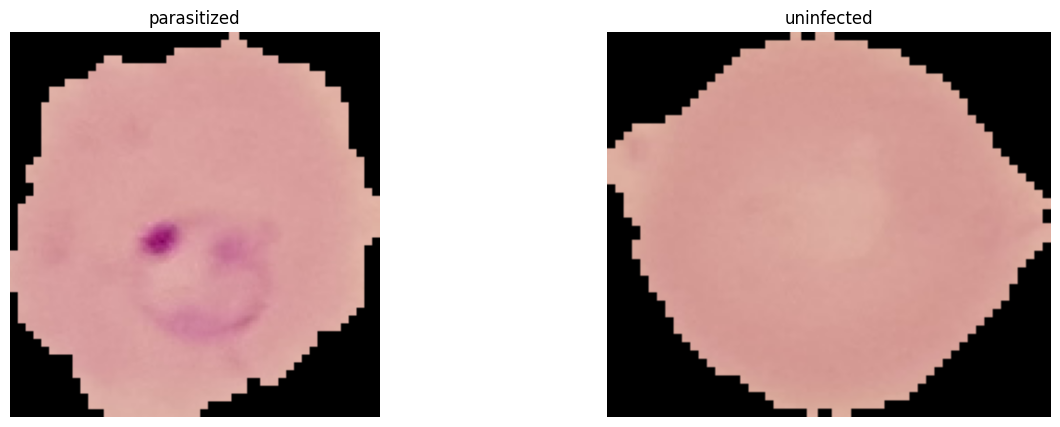

In [5]:
fig , ax = plt.subplots(1, 2 , figsize= (15,5))

parasitized_img = cv2.cvtColor(cv2.imread(parasitized), cv2.COLOR_BGR2RGB)
uninfected_img = cv2.cvtColor(cv2.imread(uninfected), cv2.COLOR_BGR2RGB)

ax[0].imshow(parasitized_img)
ax[1].imshow(uninfected_img)

ax[0].axis('off')
ax[1].axis('off')

ax[0].set_title('parasitized')
ax[1].set_title('uninfected')

plt.show()

In [6]:
print('parasitized' , parasitized_img.shape)
print('uninfected' , uninfected_img.shape)

parasitized (148, 142, 3)
uninfected (139, 160, 3)


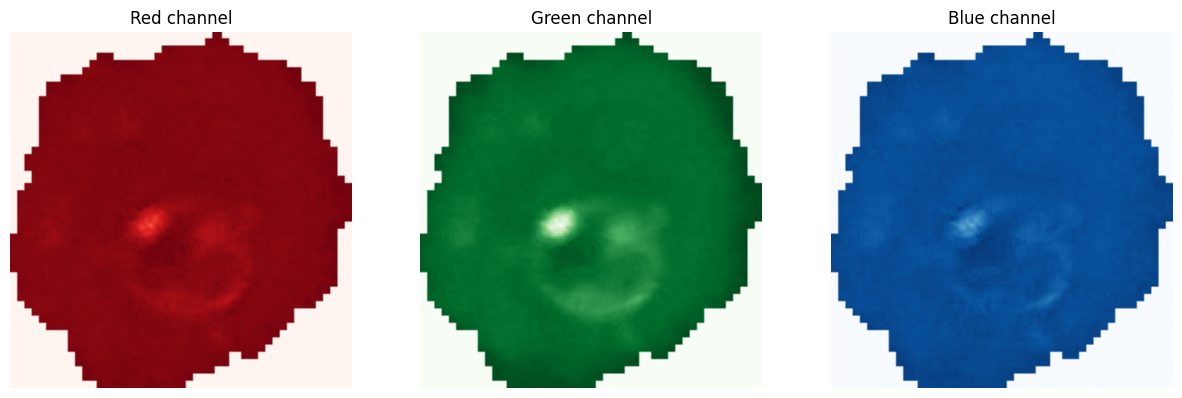

In [7]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(parasitized_img[:,:,0], cmap='Reds')
axs[1].imshow(parasitized_img[:,:,1], cmap='Greens')
axs[2].imshow(parasitized_img[:,:,2], cmap='Blues')
axs[0].axis('off')
axs[1].axis('off')
axs[2].axis('off')
axs[0].set_title('Red channel')
axs[1].set_title('Green channel')
axs[2].set_title('Blue channel')
plt.show()

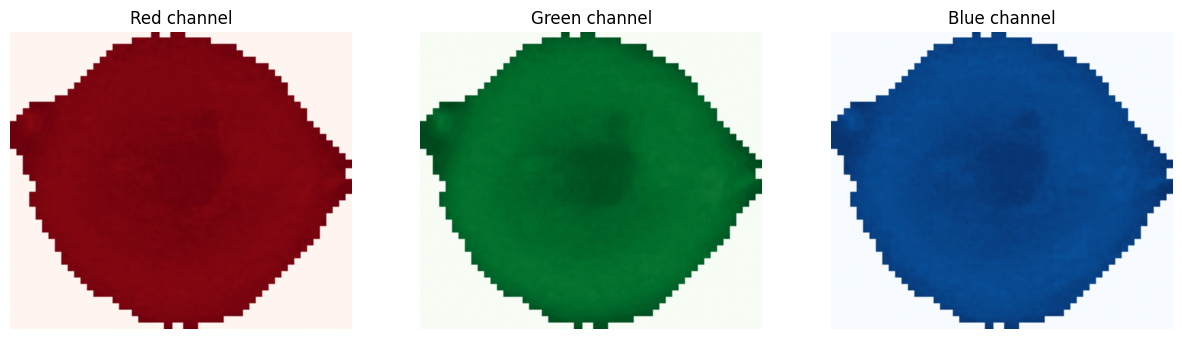

In [8]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(uninfected_img[:,:,0], cmap='Reds')
axs[1].imshow(uninfected_img[:,:,1], cmap='Greens')
axs[2].imshow(uninfected_img[:,:,2], cmap='Blues')
axs[0].axis('off')
axs[1].axis('off')
axs[2].axis('off')
axs[0].set_title('Red channel')
axs[1].set_title('Green channel')
axs[2].set_title('Blue channel')
plt.show()

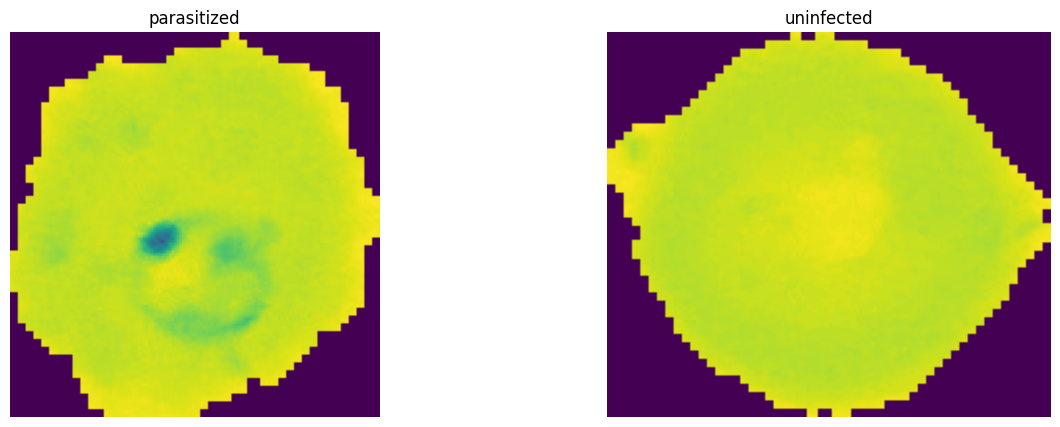

In [9]:
fig , ax = plt.subplots(1, 2 , figsize= (15,5))

parasitized_imggray = cv2.cvtColor(parasitized_img, cv2.COLOR_RGB2GRAY)
uninfected_imggray = cv2.cvtColor(uninfected_img, cv2.COLOR_RGB2GRAY)

ax[0].imshow(parasitized_imggray)
ax[1].imshow(uninfected_imggray)

ax[0].axis('off')
ax[1].axis('off')

ax[0].set_title('parasitized')
ax[1].set_title('uninfected')

plt.show()

In [10]:
print('parasitized gray' , parasitized_imggray.shape)
print('uninfected gray' , uninfected_imggray.shape)

parasitized gray (148, 142)
uninfected gray (139, 160)


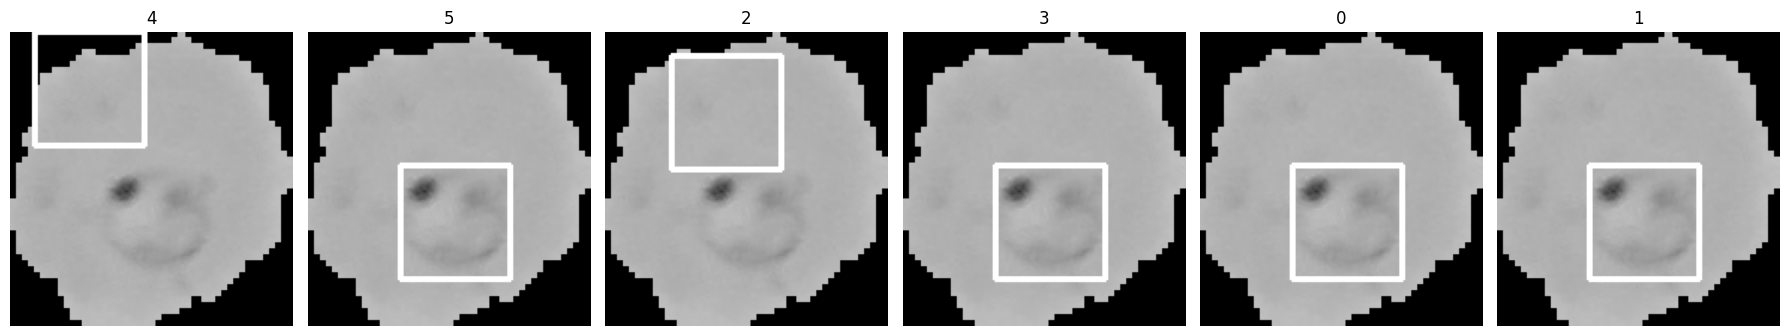

In [14]:
img = parasitized_imggray

template = cv2.cvtColor(cv2.imread(r"C:\Users\dohah\Documents\Projects\Detecting Malaria Model\MachineLearningProject\img_dataset\template.png"), cv2.COLOR_BGR2GRAY)
h, w = template.shape

methods = [ cv2.TM_CCOEFF, cv2.TM_CCOEFF_NORMED, cv2.TM_CCORR, cv2.TM_CCORR_NORMED, cv2.TM_SQDIFF, cv2.TM_SQDIFF_NORMED]

fig, ax = plt.subplots(1, 6, figsize=(18, 5))  # وسّعت الشكل

for i, method in enumerate(methods):
    img2 = img.copy()

    # Apply template matching
    result = cv2.matchTemplate(img2, template, method)
    min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(result)

    # اختيار المكان حسب نوع الطريقة
    if method in [cv2.TM_SQDIFF, cv2.TM_SQDIFF_NORMED]:
        location = min_loc
    else:
        location = max_loc

    bottom_right = (location[0] + w, location[1] + h)

    # ارسم مستطيل (لازم تستخدم لون ورقم thickness صح)
    cv2.rectangle(img2, location, bottom_right, (255, 255, 255), 2)

    # ما بدنا RGB لأن الصورة GRAY
    ax[i].imshow(img2, cmap='gray')
    ax[i].set_title(str(method))
    ax[i].axis('off')

plt.tight_layout()
plt.show()


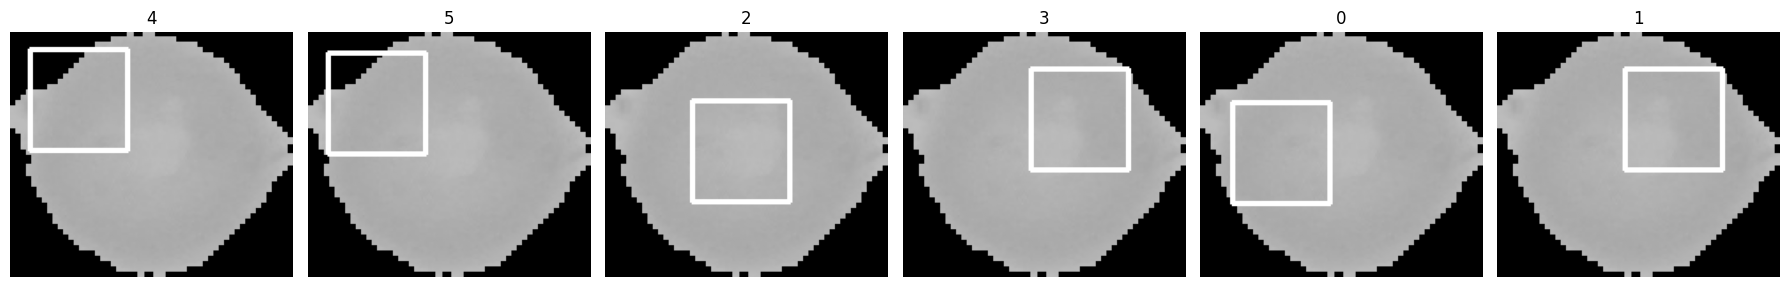

In [15]:
img = uninfected_imggray

template = cv2.cvtColor(cv2.imread(r"C:\Users\dohah\Documents\Projects\Detecting Malaria Model\MachineLearningProject\img_dataset\template.png"), cv2.COLOR_BGR2GRAY)
h, w = template.shape

methods = [ cv2.TM_CCOEFF, cv2.TM_CCOEFF_NORMED, cv2.TM_CCORR, cv2.TM_CCORR_NORMED, cv2.TM_SQDIFF, cv2.TM_SQDIFF_NORMED]

fig, ax = plt.subplots(1, 6, figsize=(18, 5))  # وسّعت الشكل

for i, method in enumerate(methods):
    img2 = img.copy()

    # Apply template matching
    result = cv2.matchTemplate(img2, template, method)
    min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(result)

    # اختيار المكان حسب نوع الطريقة
    if method in [cv2.TM_SQDIFF, cv2.TM_SQDIFF_NORMED]:
        location = min_loc
    else:
        location = max_loc

    bottom_right = (location[0] + w, location[1] + h)

    # ارسم مستطيل (لازم تستخدم لون ورقم thickness صح)
    cv2.rectangle(img2, location, bottom_right, (255, 255, 255), 2)

    # ما بدنا RGB لأن الصورة GRAY
    ax[i].imshow(img2, cmap='gray')
    ax[i].set_title(str(method))
    ax[i].axis('off')

plt.tight_layout()
plt.show()


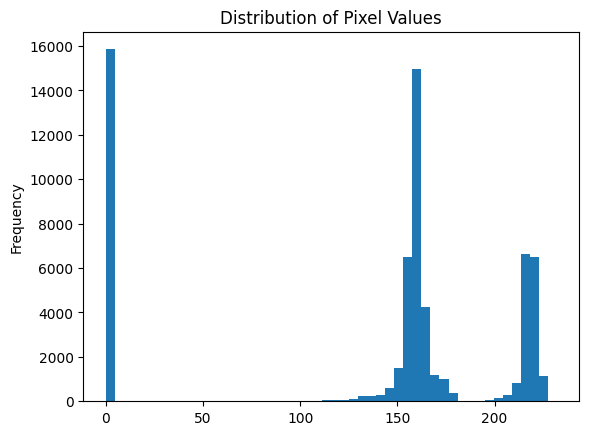

In [20]:
pd.Series(parasitized_img.flatten()).plot(kind='hist',
                                  bins=50,
                                  title='Distribution of Pixel Values')
plt.show()

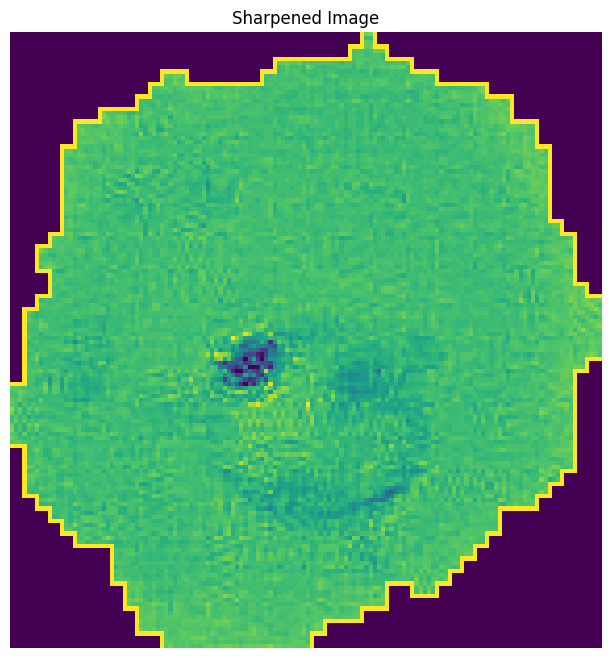

In [68]:
# Sharpen Image
kernel_sharpening = np.array([[-1,-1,-1], 
                              [-1,9,-1], 
                              [-1,-1,-1]])

sharpened = cv2.filter2D(parasitized_imggray, -1, kernel_sharpening)


fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(sharpened)
ax.axis('off')
ax.set_title('Sharpened Image')
plt.show()

(np.float64(-0.5), np.float64(141.5), np.float64(147.5), np.float64(-0.5))

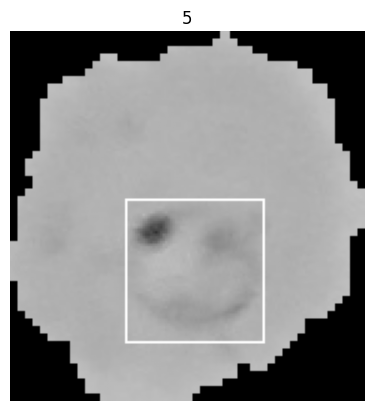

In [67]:
img2 = parasitized_imggray.copy()
template = cv2.cvtColor(cv2.imread(r"C:\Users\dohah\Documents\Projects\Detecting Malaria Model\MachineLearningProject\img_dataset\template.png"), cv2.COLOR_BGR2GRAY)
h, w = template.shape
ax = plt.subplot() 

# methods = [ cv2.TM_CCOEFF, cv2.TM_CCOEFF_NORMED, cv2.TM_CCORR, cv2.TM_CCORR_NORMED, cv2.TM_SQDIFF, cv2.TM_SQDIFF_NORMED]

result = cv2.matchTemplate(img2, template, cv2.TM_CCOEFF_NORMED)
min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(result)
location = max_loc

bottom_right = (location[0] + w, location[1] + h)
xc = cv2.rectangle(img2, location, bottom_right, (255, 255, 255), 1)

ax.imshow(img2, cmap='gray')
ax.set_title(str(cv2.TM_CCOEFF_NORMED))
ax.axis('off')

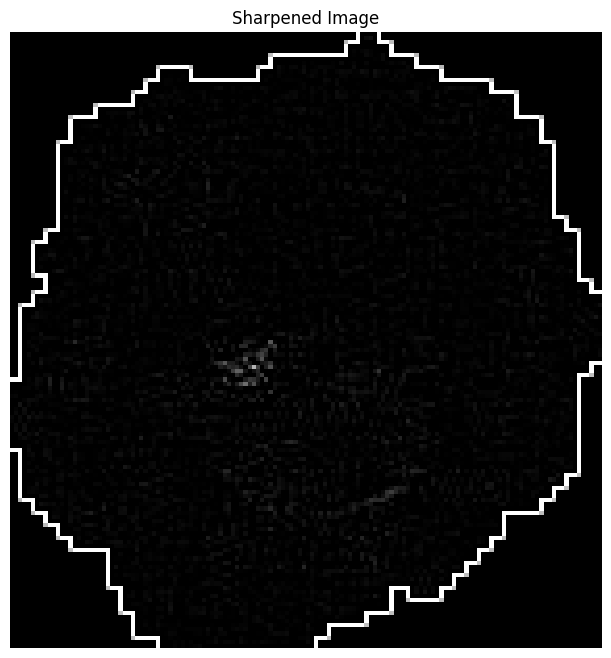

In [90]:
kernel_sharpening = np.array([[1,1,1], 
                              [1,-8,1], 
                              [1,1,1]])

sharpened = cv2.filter2D(parasitized_imggray , -1, kernel_sharpening)


fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(sharpened , cmap='gray')
ax.axis('off')
ax.set_title('Sharpened Image')
plt.show()

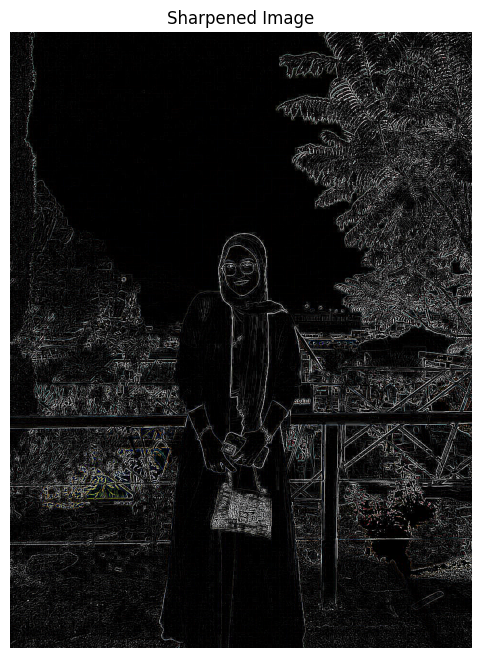

In [65]:
# Sharpen Image
kernel_sharpening = np.array([[1,1,1], 
                              [1,-8,1], 
                              [1,1,1]])

sharpened1 = cv2.filter2D(cv2.imread(r"C:\Users\dohah\Pictures\mobile flash\dodo.jpg"), -1, kernel_sharpening)


fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(sharpened1)
ax.axis('off')
ax.set_title('Sharpened Image')
plt.show()